In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load existing feature matrix
df = pd.read_csv("../data/features/nifty50_features.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (1110, 16)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'return', 'log_return', 'volatility_20d', 'rsi_14', 'macd', 'macd_signal', 'macd_histogram', 'atr_14', 'volume_change', 'volume_ma_20']


,Date,Open,High,Low,Close,Volume,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
0,2022-02-01,17529.449219,17622.400391,17244.550781,17576.849609,386400,0.013668,0.013575,0.010512,60.680331,-117.236885,-45.520134,-71.716751,290.674486,0.201119,281070.0
1,2022-02-02,17706.199219,17794.599609,17674.800781,17780.000000,271200,0.011558,0.011492,0.010586,64.074128,-88.394175,-54.094942,-34.299233,285.465594,-0.298137,282260.0
2,2022-02-03,17767.750000,17781.150391,17511.150391,17560.199219,226600,-0.012362,-0.012439,0.010804,58.218993,-82.323235,-59.740601,-22.582634,284.360909,-0.164454,281015.0
3,2022-02-04,17590.199219,17617.800781,17462.550781,17516.300781,261400,-0.002500,-0.002503,0.010602,57.096792,-80.130513,-63.818583,-16.311930,275.138701,0.153575,282260.0
4,2022-02-07,17456.300781,17536.750000,17119.400391,17213.599609,265000,-0.017281,-0.017432,0.011181,49.947410,-101.646503,-71.384167,-30.262336,285.296623,0.013772,283545.0


In [32]:
date_column = "Date"
feature_columns = [
    "return",
    "log_return",
    "volatility_20d",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_histogram",
    "atr_14",
    "volume_change",
    "volume_ma_20"
]

print("Number of features:", len(feature_columns))
print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

Number of features: 10

Features:
- return
- log_return
- volatility_20d
- rsi_14
- macd
- macd_signal
- macd_histogram
- atr_14
- volume_change
- volume_ma_20


In [33]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df[feature_columns].isnull().sum())

Data types:
Date              datetime64[ns]
Open                     float64
High                     float64
Low                      float64
Close                    float64
Volume                     int64
return                   float64
log_return               float64
volatility_20d           float64
rsi_14                   float64
macd                     float64
macd_signal              float64
macd_histogram           float64
atr_14                   float64
volume_change            float64
volume_ma_20             float64
dtype: object

Missing values:
return            0
log_return        0
volatility_20d    0
rsi_14            0
macd              0
macd_signal       0
macd_histogram    0
atr_14            0
volume_change     0
volume_ma_20      0
dtype: int64


In [34]:
summary = df[feature_columns].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
return,1110.0,0.000345,0.008706,-0.059294,-0.004146,0.000428,0.005304,0.038183
log_return,1110.0,0.000307,0.008718,-0.061124,-0.004155,0.000428,0.005290,0.037472
volatility_20d,1110.0,0.008126,0.003323,0.003161,0.005821,0.007278,0.009370,0.019047
rsi_14,1110.0,53.423134,12.094756,21.788395,44.527750,53.556848,61.820186,85.256264
macd,1110.0,39.547114,189.926942,-662.927251,-85.865293,56.206256,168.767321,451.083428
macd_signal,1110.0,39.263136,177.536678,-614.943938,-84.523843,51.803532,164.218122,413.985339
macd_histogram,1110.0,0.283979,60.455316,-193.013144,-41.710485,-3.222406,41.140338,230.579215
atr_14,1110.0,237.207994,64.839311,128.208300,192.560402,230.662389,275.634351,496.312895
volume_change,1110.0,0.058431,0.603207,-1.000000,-0.138914,-0.004739,0.155646,12.094421
volume_ma_20,1110.0,308324.792793,63180.788799,201250.000000,266841.250000,290505.000000,334007.500000,525685.000000


In [35]:
summary["skewness"] = df[feature_columns].skew()

summary["skewness"] 

return            -0.360357
log_return        -0.439611
volatility_20d     1.443099
rsi_14             0.022929
macd              -0.495032
macd_signal       -0.434682
macd_histogram     0.348203
atr_14             0.830666
volume_change     12.274429
volume_ma_20       1.186977
Name: skewness, dtype: float64

In [36]:
summary = summary[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness"
    ]
]

summary

,count,mean,std,min,25%,50%,75%,max,skewness
return,1110.0,0.000345,0.008706,-0.059294,-0.004146,0.000428,0.005304,0.038183,-0.360357
log_return,1110.0,0.000307,0.008718,-0.061124,-0.004155,0.000428,0.005290,0.037472,-0.439611
volatility_20d,1110.0,0.008126,0.003323,0.003161,0.005821,0.007278,0.009370,0.019047,1.443099
rsi_14,1110.0,53.423134,12.094756,21.788395,44.527750,53.556848,61.820186,85.256264,0.022929
macd,1110.0,39.547114,189.926942,-662.927251,-85.865293,56.206256,168.767321,451.083428,-0.495032
macd_signal,1110.0,39.263136,177.536678,-614.943938,-84.523843,51.803532,164.218122,413.985339,-0.434682
macd_histogram,1110.0,0.283979,60.455316,-193.013144,-41.710485,-3.222406,41.140338,230.579215,0.348203
atr_14,1110.0,237.207994,64.839311,128.208300,192.560402,230.662389,275.634351,496.312895,0.830666
volume_change,1110.0,0.058431,0.603207,-1.000000,-0.138914,-0.004739,0.155646,12.094421,12.274429
volume_ma_20,1110.0,308324.792793,63180.788799,201250.000000,266841.250000,290505.000000,334007.500000,525685.000000,1.186977


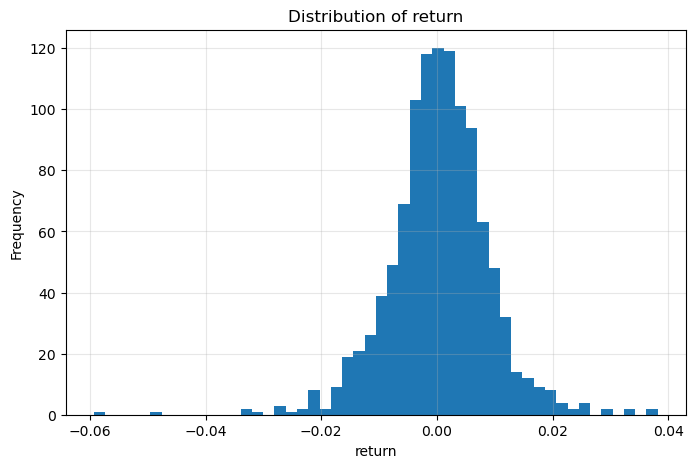

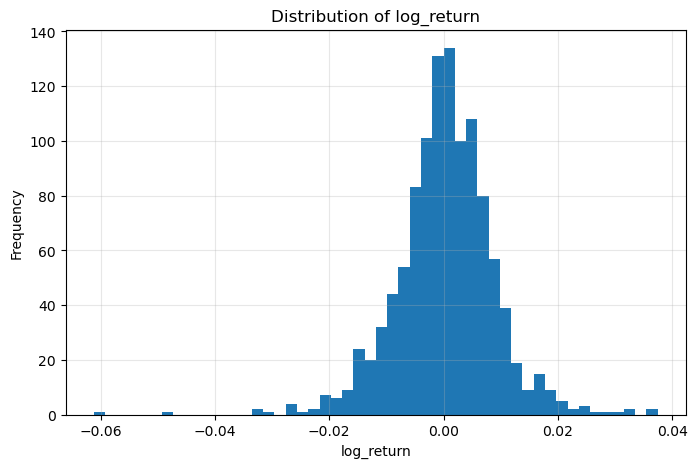

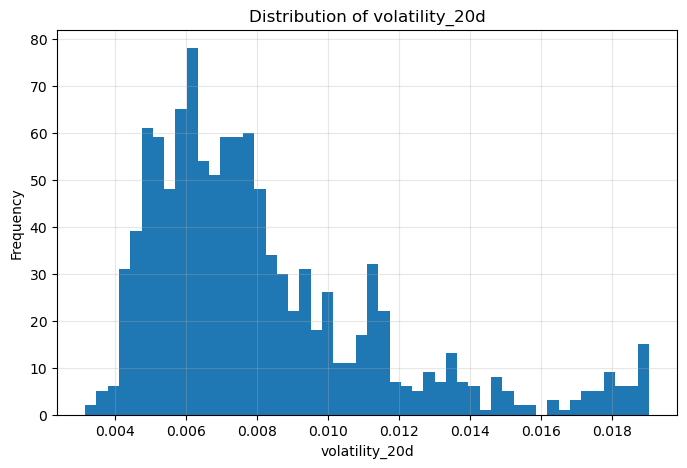

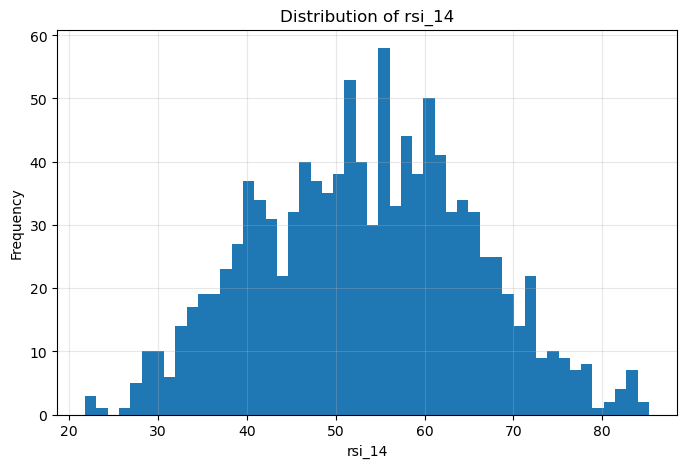

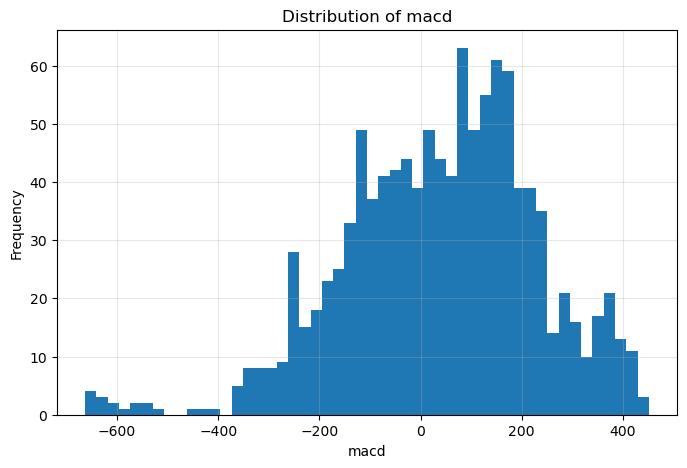

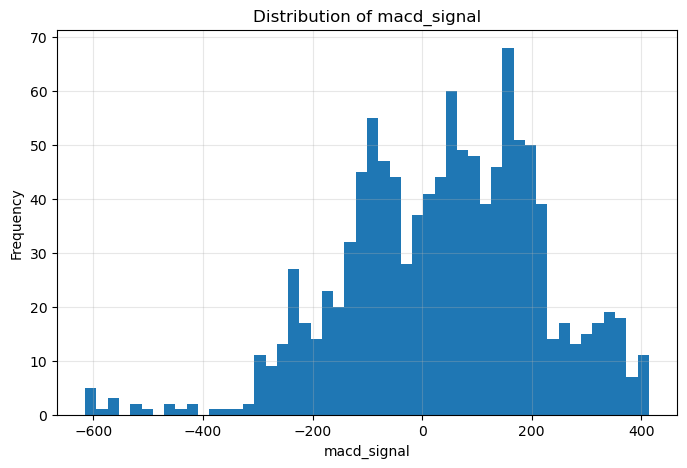

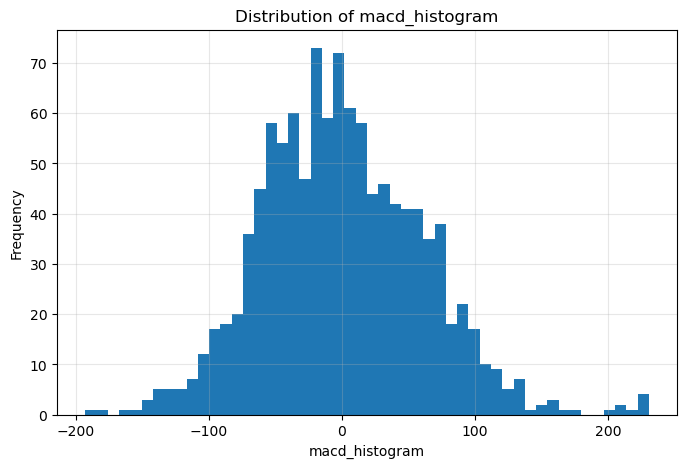

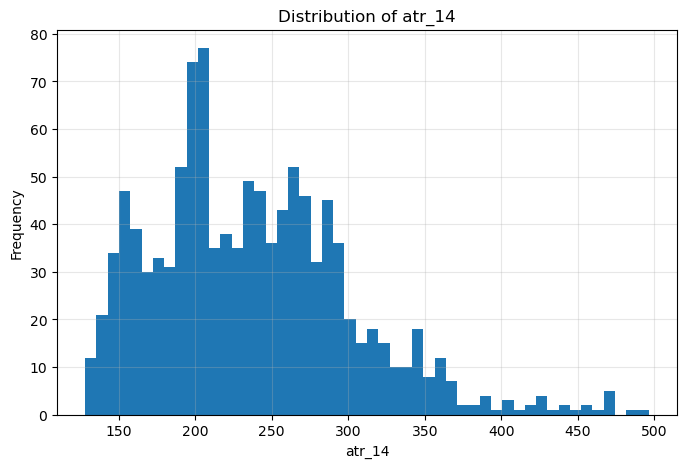

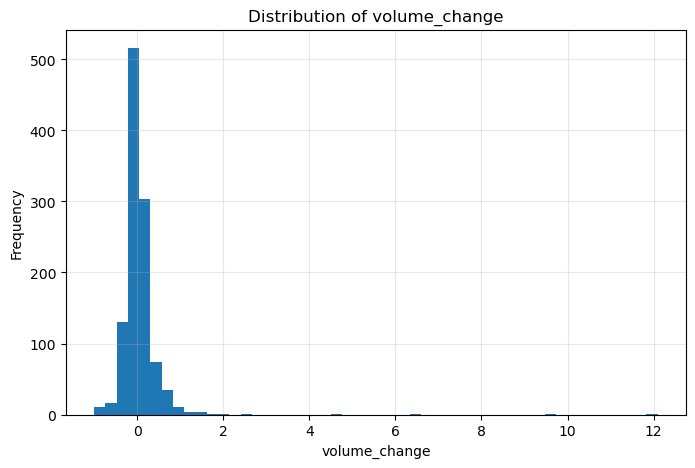

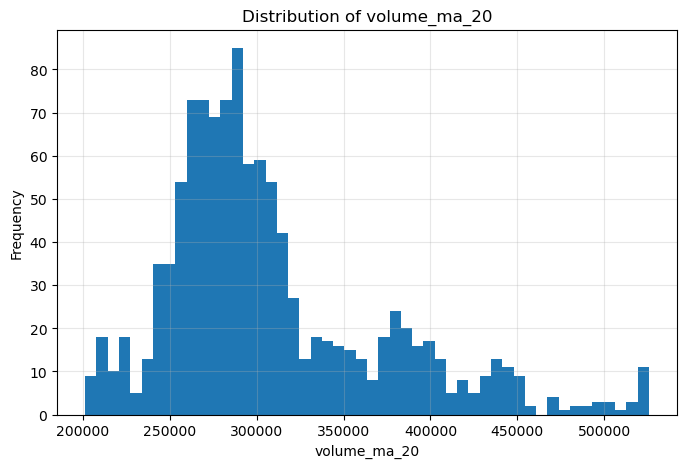

In [37]:
for feature in feature_columns:
    plt.figure(figsize=(8, 5))
    
    plt.hist(df[feature].dropna(), bins=50)
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    
    plt.show()

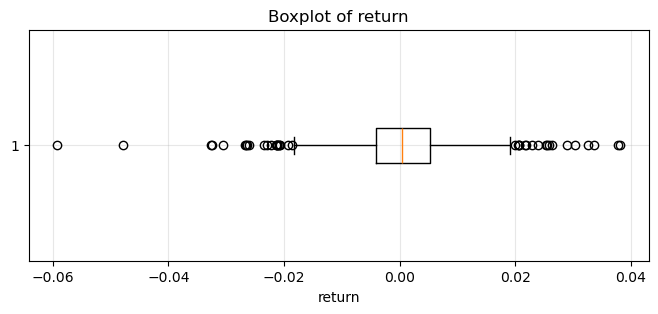

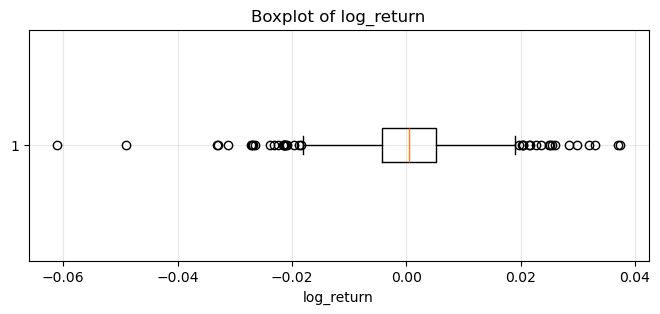

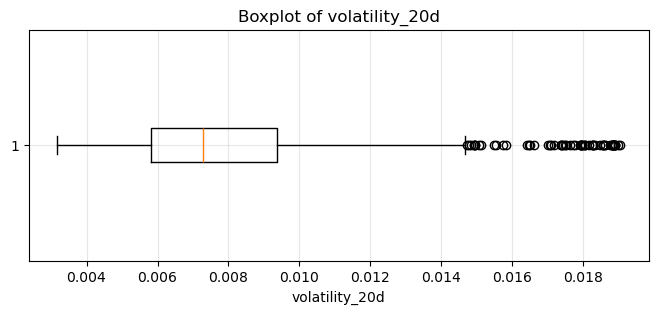

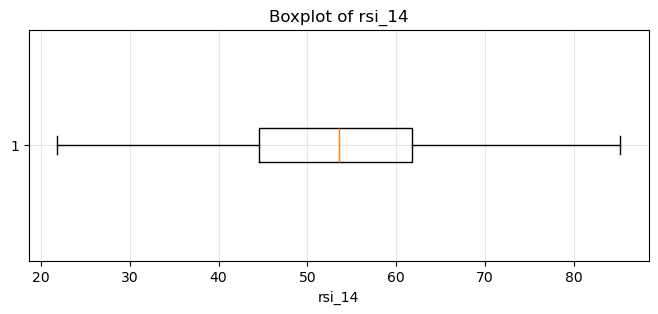

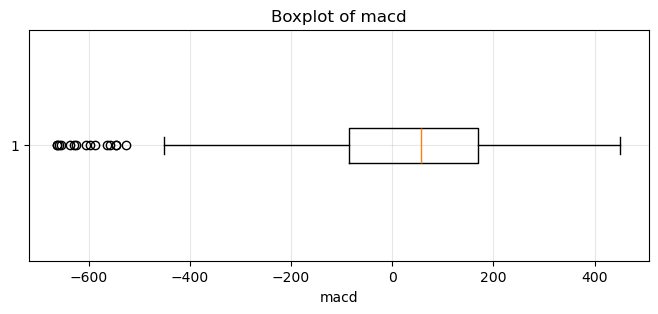

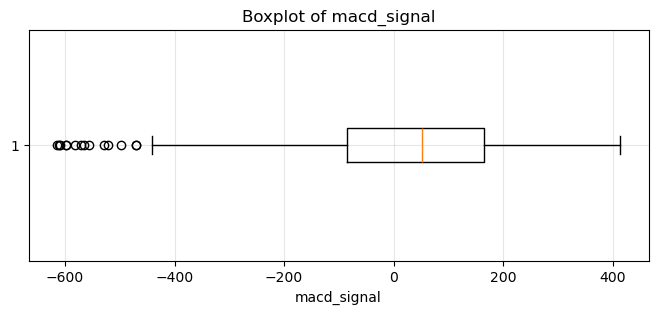

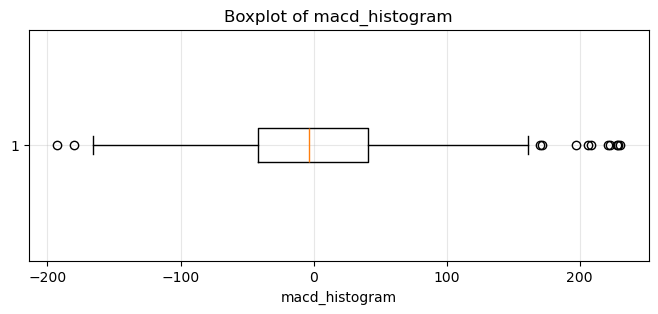

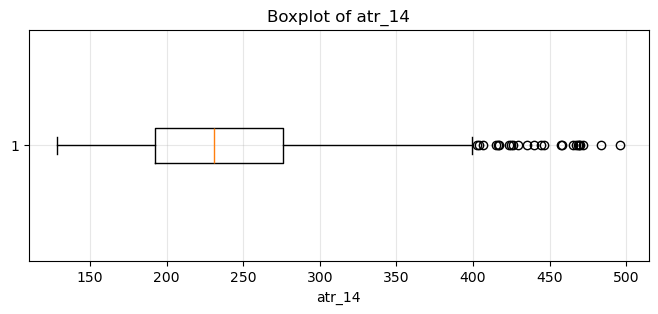

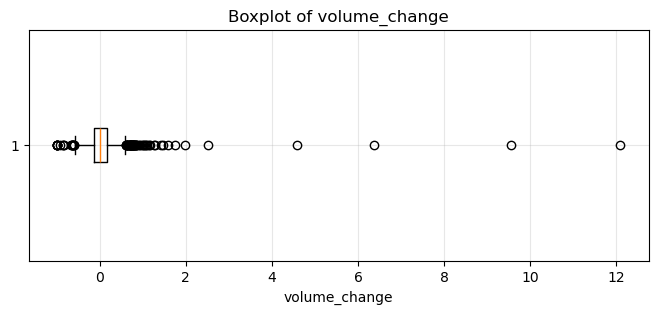

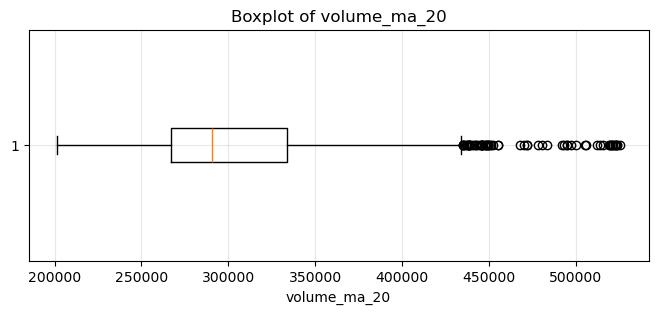

In [38]:
for feature in feature_columns:
    plt.figure(figsize=(8, 3))
    
    plt.boxplot(df[feature].dropna(), vert=False)
    
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.grid(alpha=0.3)
    
    plt.show()

In [40]:
outlier_results = []
for feature in feature_columns:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )
    
    outlier_count = outlier_mask.sum()
    total_count = df[feature].notna().sum()
    
    outlier_percentage = (
        outlier_count / total_count
    ) * 100
    
    outlier_results.append({
        "feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })

In [41]:
outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,return,-0.004146,0.005304,0.009450,-0.018321,0.019479,39,3.513514
1,log_return,-0.004155,0.005290,0.009445,-0.018322,0.019456,40,3.603604
2,volatility_20d,0.005821,0.009370,0.003549,0.000497,0.014694,66,5.945946
3,rsi_14,44.527750,61.820186,17.292437,18.589094,87.758841,0,0.000000
4,macd,-85.865293,168.767321,254.632614,-467.814215,550.716243,15,1.351351
5,macd_signal,-84.523843,164.218122,248.741964,-457.636789,537.331069,14,1.261261
6,macd_histogram,-41.710485,41.140338,82.850824,-165.986721,165.416574,12,1.081081
7,atr_14,192.560402,275.634351,83.073950,67.949477,400.245276,24,2.162162
8,volume_change,-0.138914,0.155646,0.294560,-0.580754,0.597486,74,6.666667
9,volume_ma_20,266841.250000,334007.500000,67166.250000,166091.875000,434756.875000,65,5.855856


In [42]:
outlier_summary.sort_values(
    by="outlier_percentage",
    ascending=False
)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
8,volume_change,-0.138914,0.155646,0.294560,-0.580754,0.597486,74,6.666667
2,volatility_20d,0.005821,0.009370,0.003549,0.000497,0.014694,66,5.945946
9,volume_ma_20,266841.250000,334007.500000,67166.250000,166091.875000,434756.875000,65,5.855856
1,log_return,-0.004155,0.005290,0.009445,-0.018322,0.019456,40,3.603604
0,return,-0.004146,0.005304,0.009450,-0.018321,0.019479,39,3.513514
7,atr_14,192.560402,275.634351,83.073950,67.949477,400.245276,24,2.162162
4,macd,-85.865293,168.767321,254.632614,-467.814215,550.716243,15,1.351351
5,macd_signal,-84.523843,164.218122,248.741964,-457.636789,537.331069,14,1.261261
6,macd_histogram,-41.710485,41.140338,82.850824,-165.986721,165.416574,12,1.081081
3,rsi_14,44.527750,61.820186,17.292437,18.589094,87.758841,0,0.000000


In [44]:
def get_outliers(feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )
    
    return df.loc[
        mask,
        [date_column, feature]
    ].sort_values(by=feature)

In [45]:
return_outliers = get_outliers("return")

return_outliers.head(10)

,Date,return
575,2024-06-04,-0.059294
17,2022-02-24,-0.047781
1020,2026-03-19,-0.032621
785,2025-04-07,-0.032433
9,2022-02-14,-0.030616
617,2024-08-05,-0.026786
72,2022-05-19,-0.026533
89,2022-06-13,-0.026380
1022,2026-03-23,-0.026038
23,2022-03-07,-0.023527


In [46]:
return_outliers.tail(10)

,Date,return
18,2022-02-25,0.025262
989,2026-02-03,0.025476
143,2022-08-30,0.025784
70,2022-05-17,0.026322
73,2022-05-20,0.028891
10,2022-02-15,0.030259
574,2024-06-03,0.032542
576,2024-06-05,0.033624
1031,2026-04-08,0.037784
806,2025-05-12,0.038183


In [47]:
for feature in feature_columns:
    outliers = get_outliers(feature)
    
    print("\n" + "=" * 60)
    print(f"FEATURE: {feature}")
    print(f"Number of outliers: {len(outliers)}")
    print("=" * 60)
    
    print(outliers.head(5))


FEATURE: return
Number of outliers: 39
           Date    return
575  2024-06-04 -0.059294
17   2022-02-24 -0.047781
1020 2026-03-19 -0.032621
785  2025-04-07 -0.032433
9    2022-02-14 -0.030616

FEATURE: log_return
Number of outliers: 40
           Date  log_return
575  2024-06-04   -0.061124
17   2022-02-24   -0.048960
1020 2026-03-19   -0.033165
785  2025-04-07   -0.032970
9    2022-02-14   -0.031095

FEATURE: volatility_20d
Number of outliers: 66
         Date  volatility_20d
13 2022-02-18        0.014715
74 2022-05-23        0.014770
12 2022-02-17        0.014846
79 2022-05-30        0.014911
80 2022-05-31        0.014929

FEATURE: rsi_14
Number of outliers: 0
Empty DataFrame
Columns: [Date, rsi_14]
Index: []

FEATURE: macd
Number of outliers: 15
           Date        macd
1026 2026-03-30 -662.927251
1023 2026-03-24 -662.000237
1022 2026-03-23 -658.785110
1027 2026-04-01 -654.440345
1028 2026-04-02 -637.644793

FEATURE: macd_signal
Number of outliers: 14
           Date  macd_si

In [48]:
df[date_column] = pd.to_datetime(df[date_column])

df = df.sort_values(date_column).reset_index(drop=True)

print(df[[date_column]].head())
print(df[[date_column]].tail())

        Date
0 2022-02-01
1 2022-02-02
2 2022-02-03
3 2022-02-04
4 2022-02-07
           Date
1105 2026-07-27
1106 2026-07-28
1107 2026-07-29
1108 2026-07-30
1109 2026-07-31


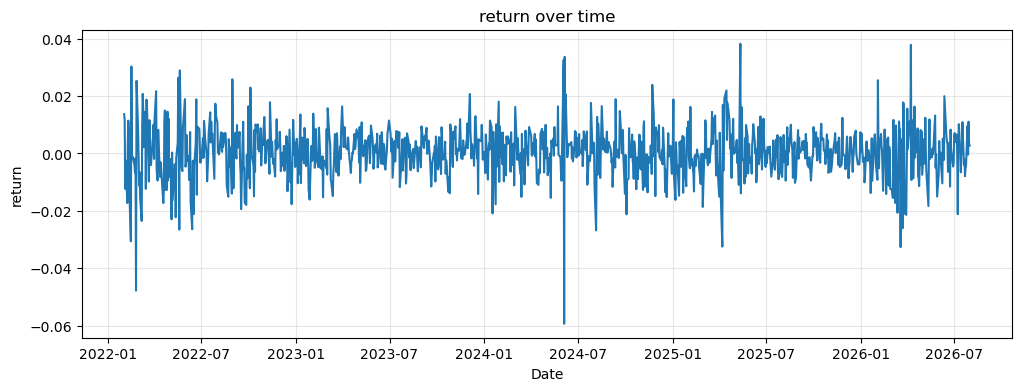

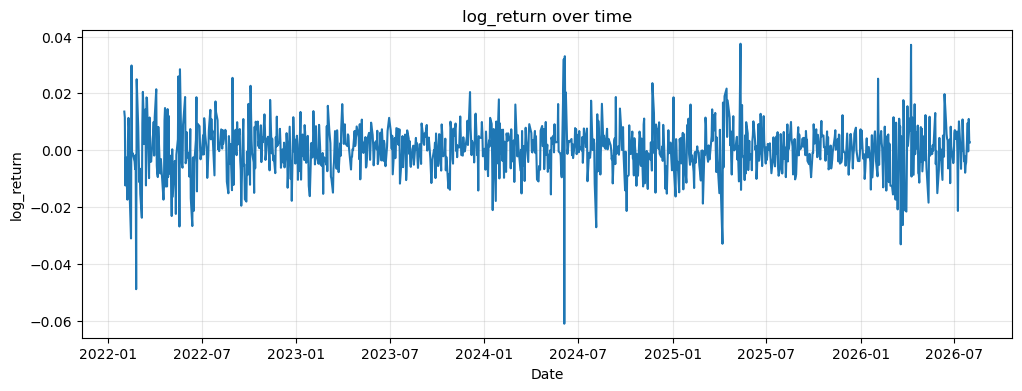

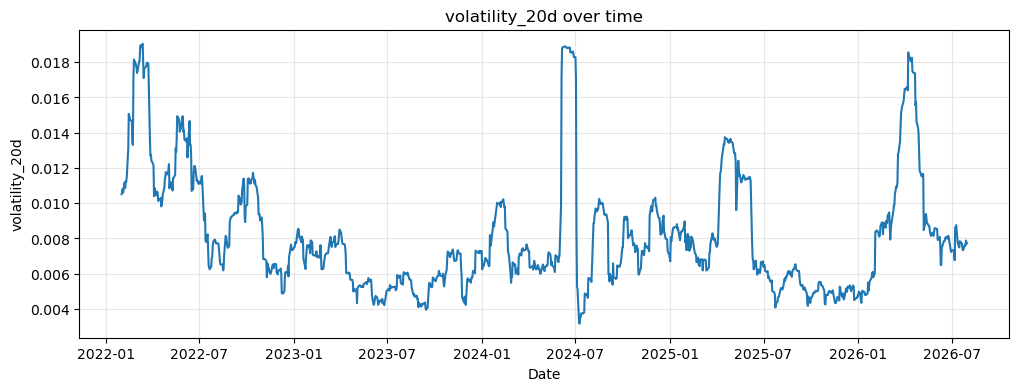

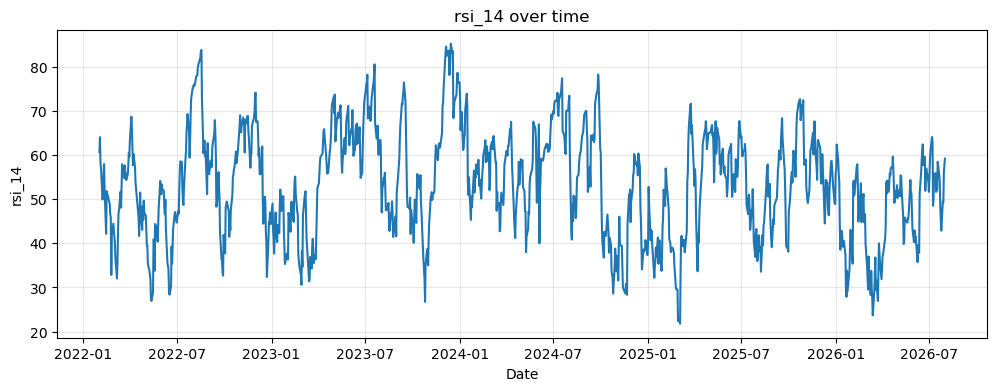

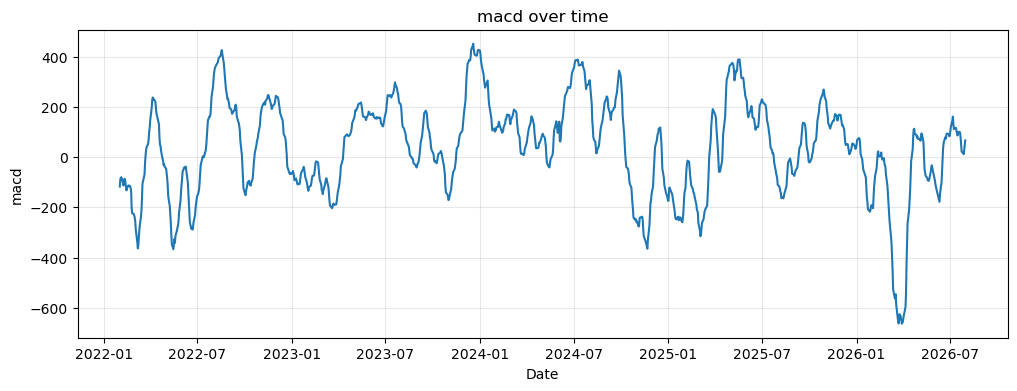

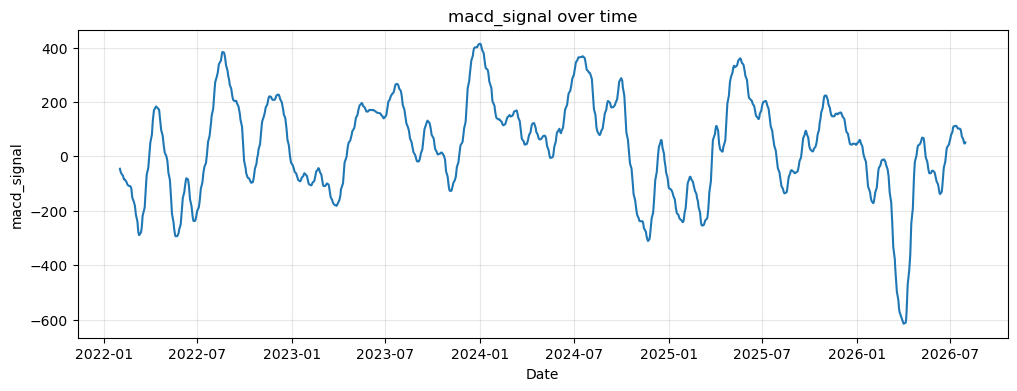

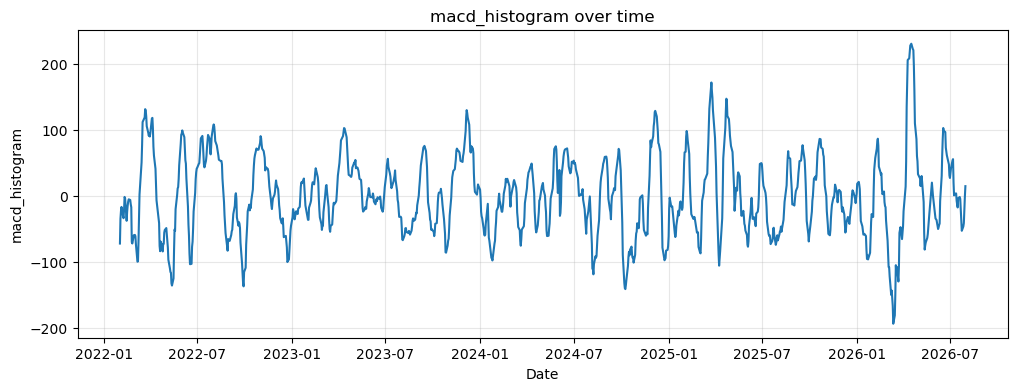

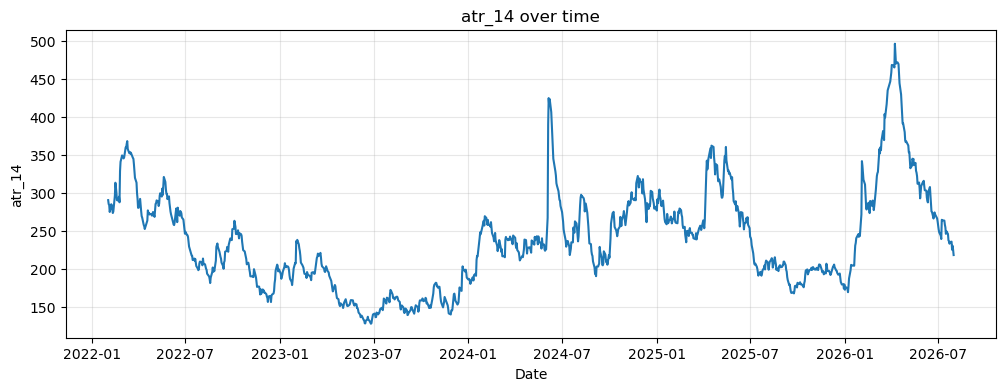

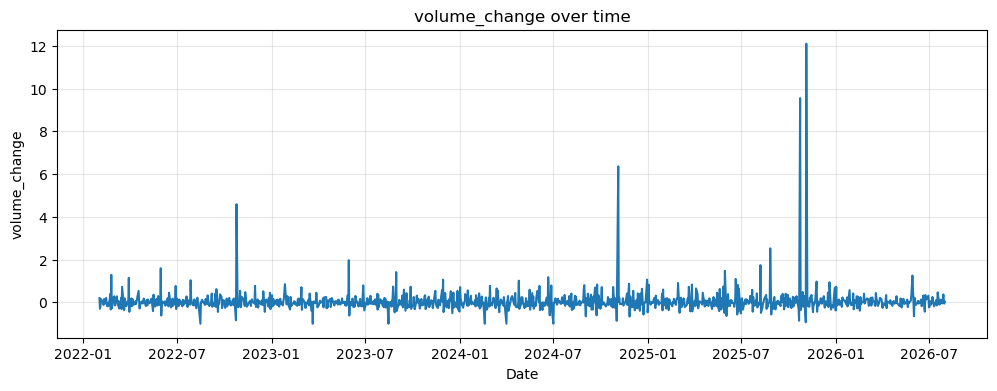

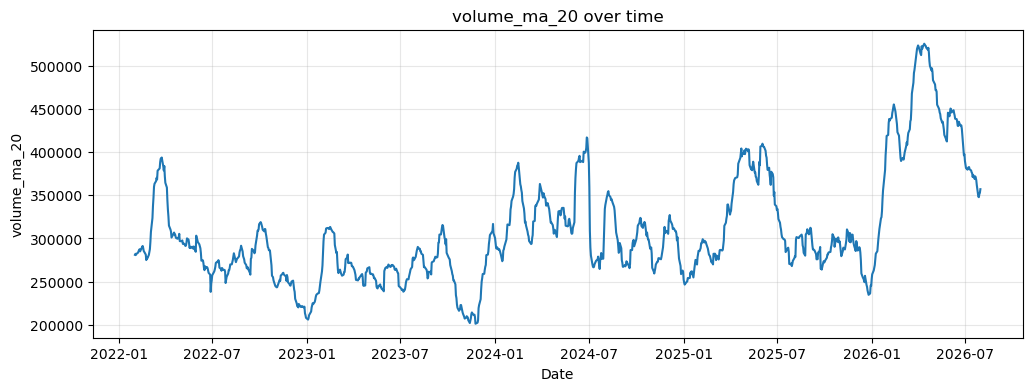

In [49]:
for feature in feature_columns:
    plt.figure(figsize=(12, 4))
    
    plt.plot(df[date_column], df[feature])
    
    plt.title(f"{feature} over time")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.grid(alpha=0.3)
    
    plt.show()

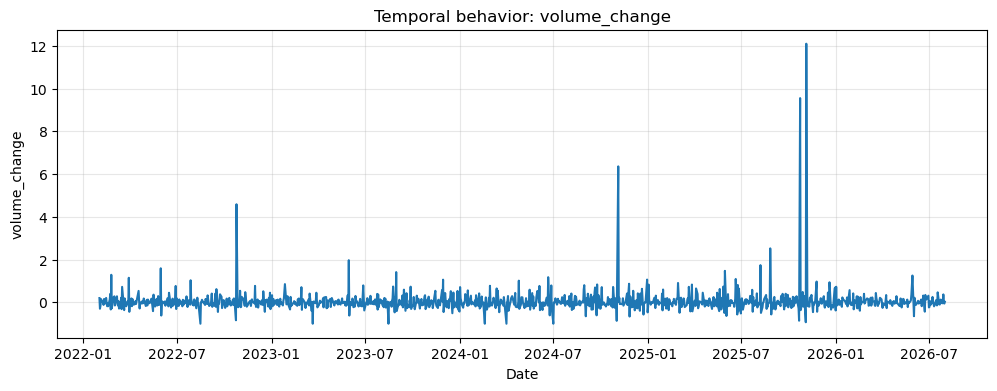

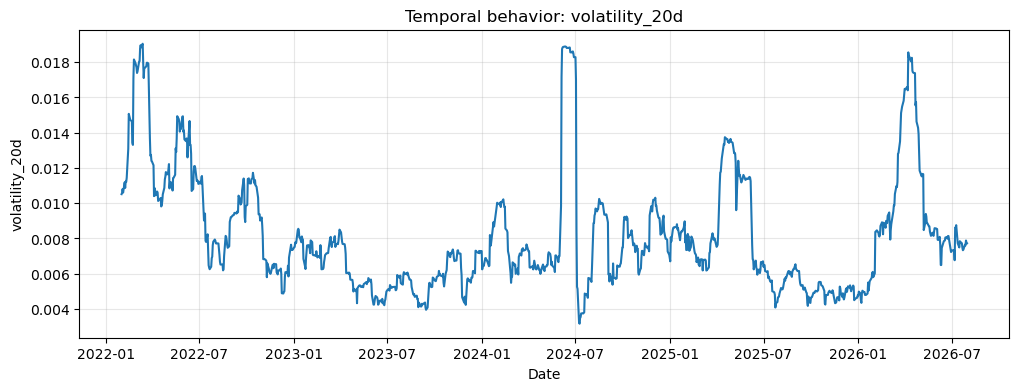

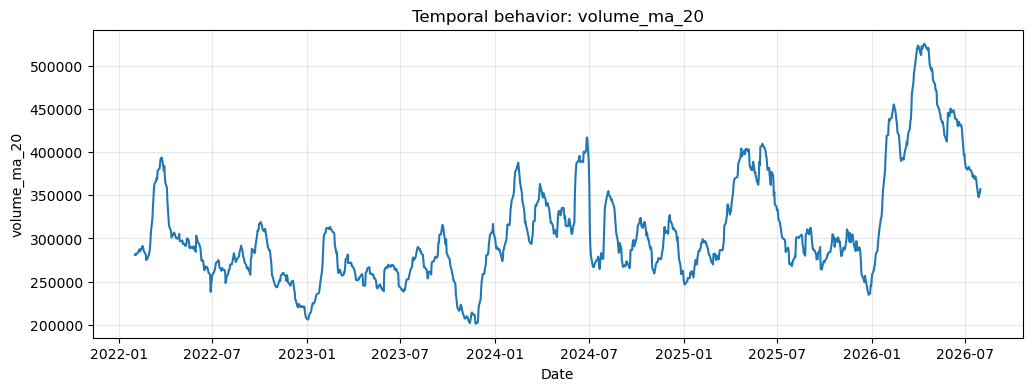

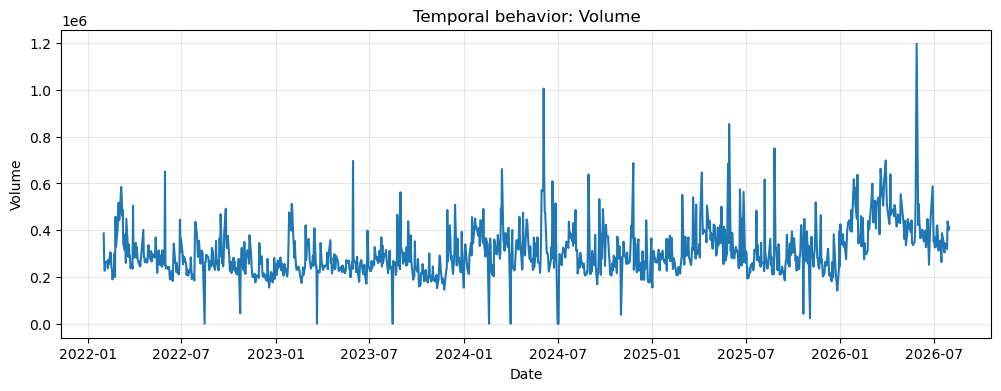

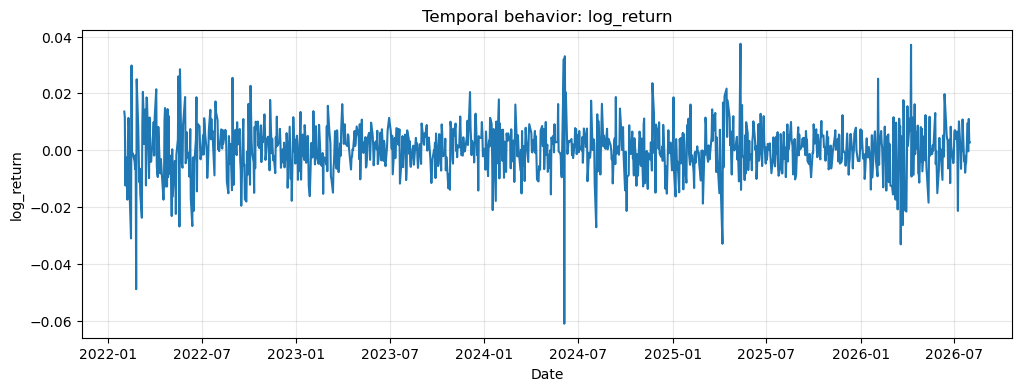

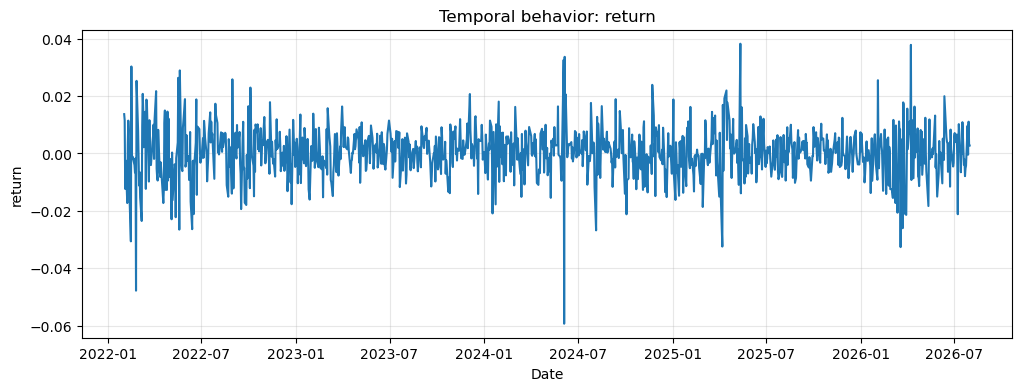

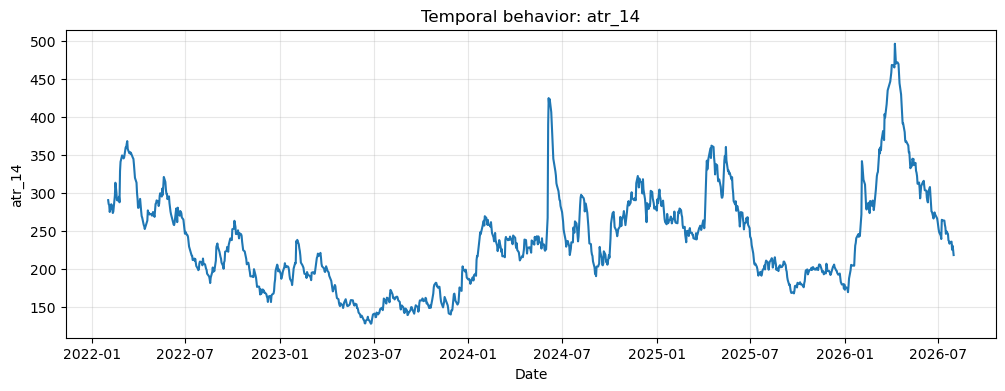

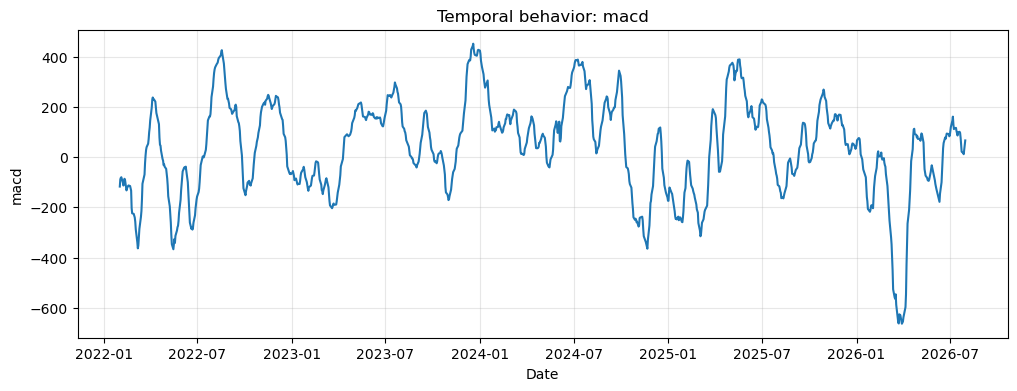

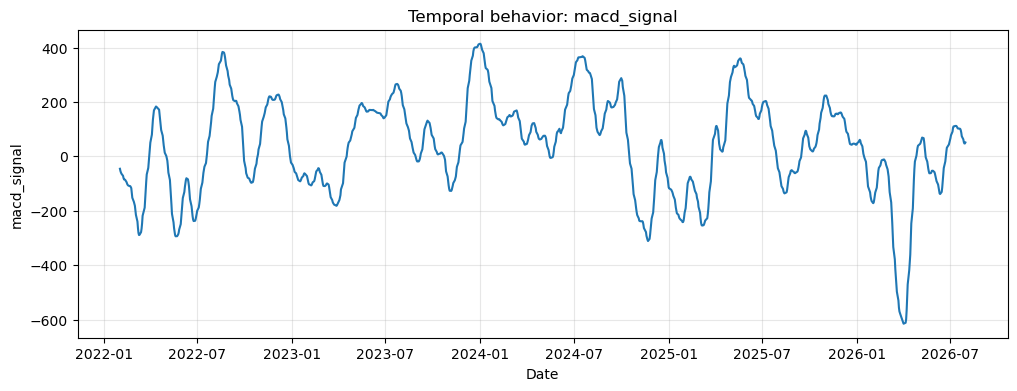

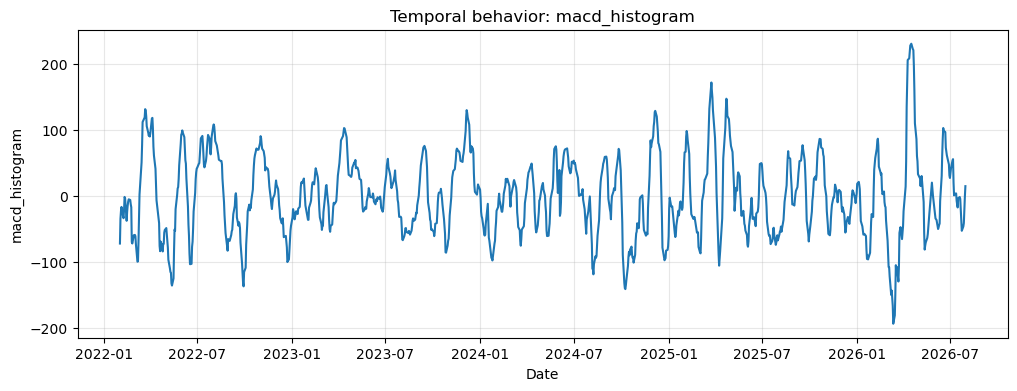

In [50]:
features_to_inspect = [
    "volume_change",
    "volatility_20d",
    "volume_ma_20",
    "Volume",
    "log_return",
    "return",
    "atr_14",
    "macd",
    "macd_signal",
    "macd_histogram"
]

for feature in features_to_inspect:
    plt.figure(figsize=(12, 4))
    
    plt.plot(
        df[date_column],
        df[feature]
    )
    
    plt.title(f"Temporal behavior: {feature}")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.grid(alpha=0.3)
    
    plt.show()

In [51]:
diagnostic = summary.copy()

diagnostic["outlier_count"] = (
    outlier_summary
    .set_index("feature")["outlier_count"]
)

diagnostic["outlier_percentage"] = (
    outlier_summary
    .set_index("feature")["outlier_percentage"]
)

diagnostic

diagnostic.sort_values(
    "outlier_percentage",
    ascending=False
)

,count,mean,std,min,25%,50%,75%,max,skewness,outlier_count,outlier_percentage
volume_change,1110.0,0.058431,0.603207,-1.000000,-0.138914,-0.004739,0.155646,12.094421,12.274429,74,6.666667
volatility_20d,1110.0,0.008126,0.003323,0.003161,0.005821,0.007278,0.009370,0.019047,1.443099,66,5.945946
volume_ma_20,1110.0,308324.792793,63180.788799,201250.000000,266841.250000,290505.000000,334007.500000,525685.000000,1.186977,65,5.855856
log_return,1110.0,0.000307,0.008718,-0.061124,-0.004155,0.000428,0.005290,0.037472,-0.439611,40,3.603604
return,1110.0,0.000345,0.008706,-0.059294,-0.004146,0.000428,0.005304,0.038183,-0.360357,39,3.513514
atr_14,1110.0,237.207994,64.839311,128.208300,192.560402,230.662389,275.634351,496.312895,0.830666,24,2.162162
macd,1110.0,39.547114,189.926942,-662.927251,-85.865293,56.206256,168.767321,451.083428,-0.495032,15,1.351351
macd_signal,1110.0,39.263136,177.536678,-614.943938,-84.523843,51.803532,164.218122,413.985339,-0.434682,14,1.261261
macd_histogram,1110.0,0.283979,60.455316,-193.013144,-41.710485,-3.222406,41.140338,230.579215,0.348203,12,1.081081
rsi_14,1110.0,53.423134,12.094756,21.788395,44.527750,53.556848,61.820186,85.256264,0.022929,0,0.000000


In [52]:
feature_diagnostics = pd.DataFrame(index=feature_columns)

feature_diagnostics["mean"] = df[feature_columns].mean()
feature_diagnostics["median"] = df[feature_columns].median()
feature_diagnostics["std"] = df[feature_columns].std()
feature_diagnostics["skewness"] = df[feature_columns].skew()
feature_diagnostics["min"] = df[feature_columns].min()
feature_diagnostics["max"] = df[feature_columns].max()

feature_diagnostics["outlier_count"] = (
    outlier_summary
    .set_index("feature")["outlier_count"]
)

feature_diagnostics["outlier_percentage"] = (
    outlier_summary
    .set_index("feature")["outlier_percentage"]
)

feature_diagnostics

,mean,median,std,skewness,min,max,outlier_count,outlier_percentage
return,0.000345,0.000428,0.008706,-0.360357,-0.059294,0.038183,39,3.513514
log_return,0.000307,0.000428,0.008718,-0.439611,-0.061124,0.037472,40,3.603604
volatility_20d,0.008126,0.007278,0.003323,1.443099,0.003161,0.019047,66,5.945946
rsi_14,53.423134,53.556848,12.094756,0.022929,21.788395,85.256264,0,0.000000
macd,39.547114,56.206256,189.926942,-0.495032,-662.927251,451.083428,15,1.351351
macd_signal,39.263136,51.803532,177.536678,-0.434682,-614.943938,413.985339,14,1.261261
macd_histogram,0.283979,-3.222406,60.455316,0.348203,-193.013144,230.579215,12,1.081081
atr_14,237.207994,230.662389,64.839311,0.830666,128.208300,496.312895,24,2.162162
volume_change,0.058431,-0.004739,0.603207,12.274429,-1.000000,12.094421,74,6.666667
volume_ma_20,308324.792793,290505.000000,63180.788799,1.186977,201250.000000,525685.000000,65,5.855856


In [53]:
return_difference = (
    df["return"] - df["log_return"]
).abs()

print("Maximum absolute difference:")
print(return_difference.max())

print("\nMean absolute difference:")
print(return_difference.mean())

print("\nMedian absolute difference:")
print(return_difference.median())

Maximum absolute difference:
0.001830596546346798

Mean absolute difference:
3.798358495179553e-05

Median absolute difference:
1.1288373611649787e-05


In [54]:
feature_ranges = pd.DataFrame({
    "min": df[feature_columns].min(),
    "max": df[feature_columns].max(),
    "range": (
        df[feature_columns].max()
        - df[feature_columns].min()
    ),
    "std": df[feature_columns].std()
})

feature_ranges.sort_values(
    "range",
    ascending=False
)

,min,max,range,std
volume_ma_20,201250.000000,525685.000000,324435.000000,63180.788799
macd,-662.927251,451.083428,1114.010679,189.926942
macd_signal,-614.943938,413.985339,1028.929278,177.536678
macd_histogram,-193.013144,230.579215,423.592359,60.455316
atr_14,128.208300,496.312895,368.104595,64.839311
rsi_14,21.788395,85.256264,63.467870,12.094756
volume_change,-1.000000,12.094421,13.094421,0.603207
log_return,-0.061124,0.037472,0.098596,0.008718
return,-0.059294,0.038183,0.097477,0.008706
volatility_20d,0.003161,0.019047,0.015886,0.003323


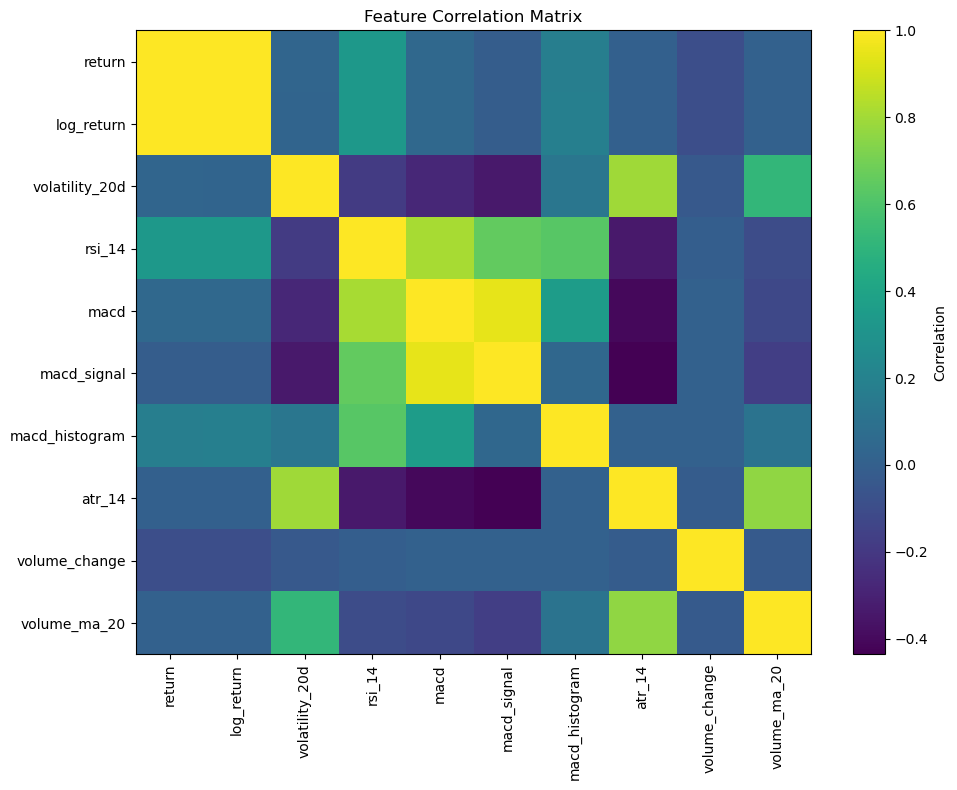

In [55]:
correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()